In [22]:
MODEL_DATASET = {
    'qwen-0.5b': 'output/results_probeonly_20260527_154159_qwen-0.5b.json',
    'llama-1b': 'output/results_probeonly_20260520_154434_llama-1b.json',
    'gemma-27b': 'output/20260508-runpod/results_probeonly_20260508_171344_gemma-27b.json',
    'qwen-32b': 'output/20260508-runpod/results_probeonly_20260508_184340_qwen-32b.json',
    'qwq-32b': 'output/20260508-runpod/results_probeonly_20260508_193619_qwq-32b.json',
    'llama-70b': 'output/20260511-runpod/results_probeonly_20260511_195030_llama-70b.json',
    'qwen-72b': 'output/20260512-runpod/results_probeonly_20260512_164943_qwen-72b.json',
    'deepseek-r1-70b': 'output/20260513-runpod/results_probeonly_20260513_200835_deepseek-r1-70b.json',
}

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

dfs = {}
for model, path in MODEL_DATASET.items():
    with open(f'../{path}') as f:
        records = json.load(f)
    dfs[model] = pd.DataFrame(records)

# Quick sanity check
for model, df in dfs.items():
    print(f"{model:25s}  n={len(df):5d}  verdict_true={df['probe_verdict'].mean():.2%}  "
          f"proj_range=[{df['probe_projection'].min():.1f}, {df['probe_projection'].max():.1f}]")

qwen-0.5b                  n= 4320  verdict_true=0.00%  proj_range=[-0.5, 1.3]
llama-1b                   n= 4320  verdict_true=32.73%  proj_range=[-0.1, 0.1]
gemma-27b                  n= 4320  verdict_true=30.67%  proj_range=[-688.0, 1856.0]
qwen-32b                   n= 4320  verdict_true=99.63%  proj_range=[-418.0, -113.0]
qwq-32b                    n= 4320  verdict_true=81.83%  proj_range=[-17.0, 9.9]
llama-70b                  n= 4320  verdict_true=60.51%  proj_range=[-0.6, 1.2]
qwen-72b                   n= 4320  verdict_true=98.59%  proj_range=[-115.5, 120.0]
deepseek-r1-70b            n= 4320  verdict_true=53.50%  proj_range=[-0.5, 0.9]


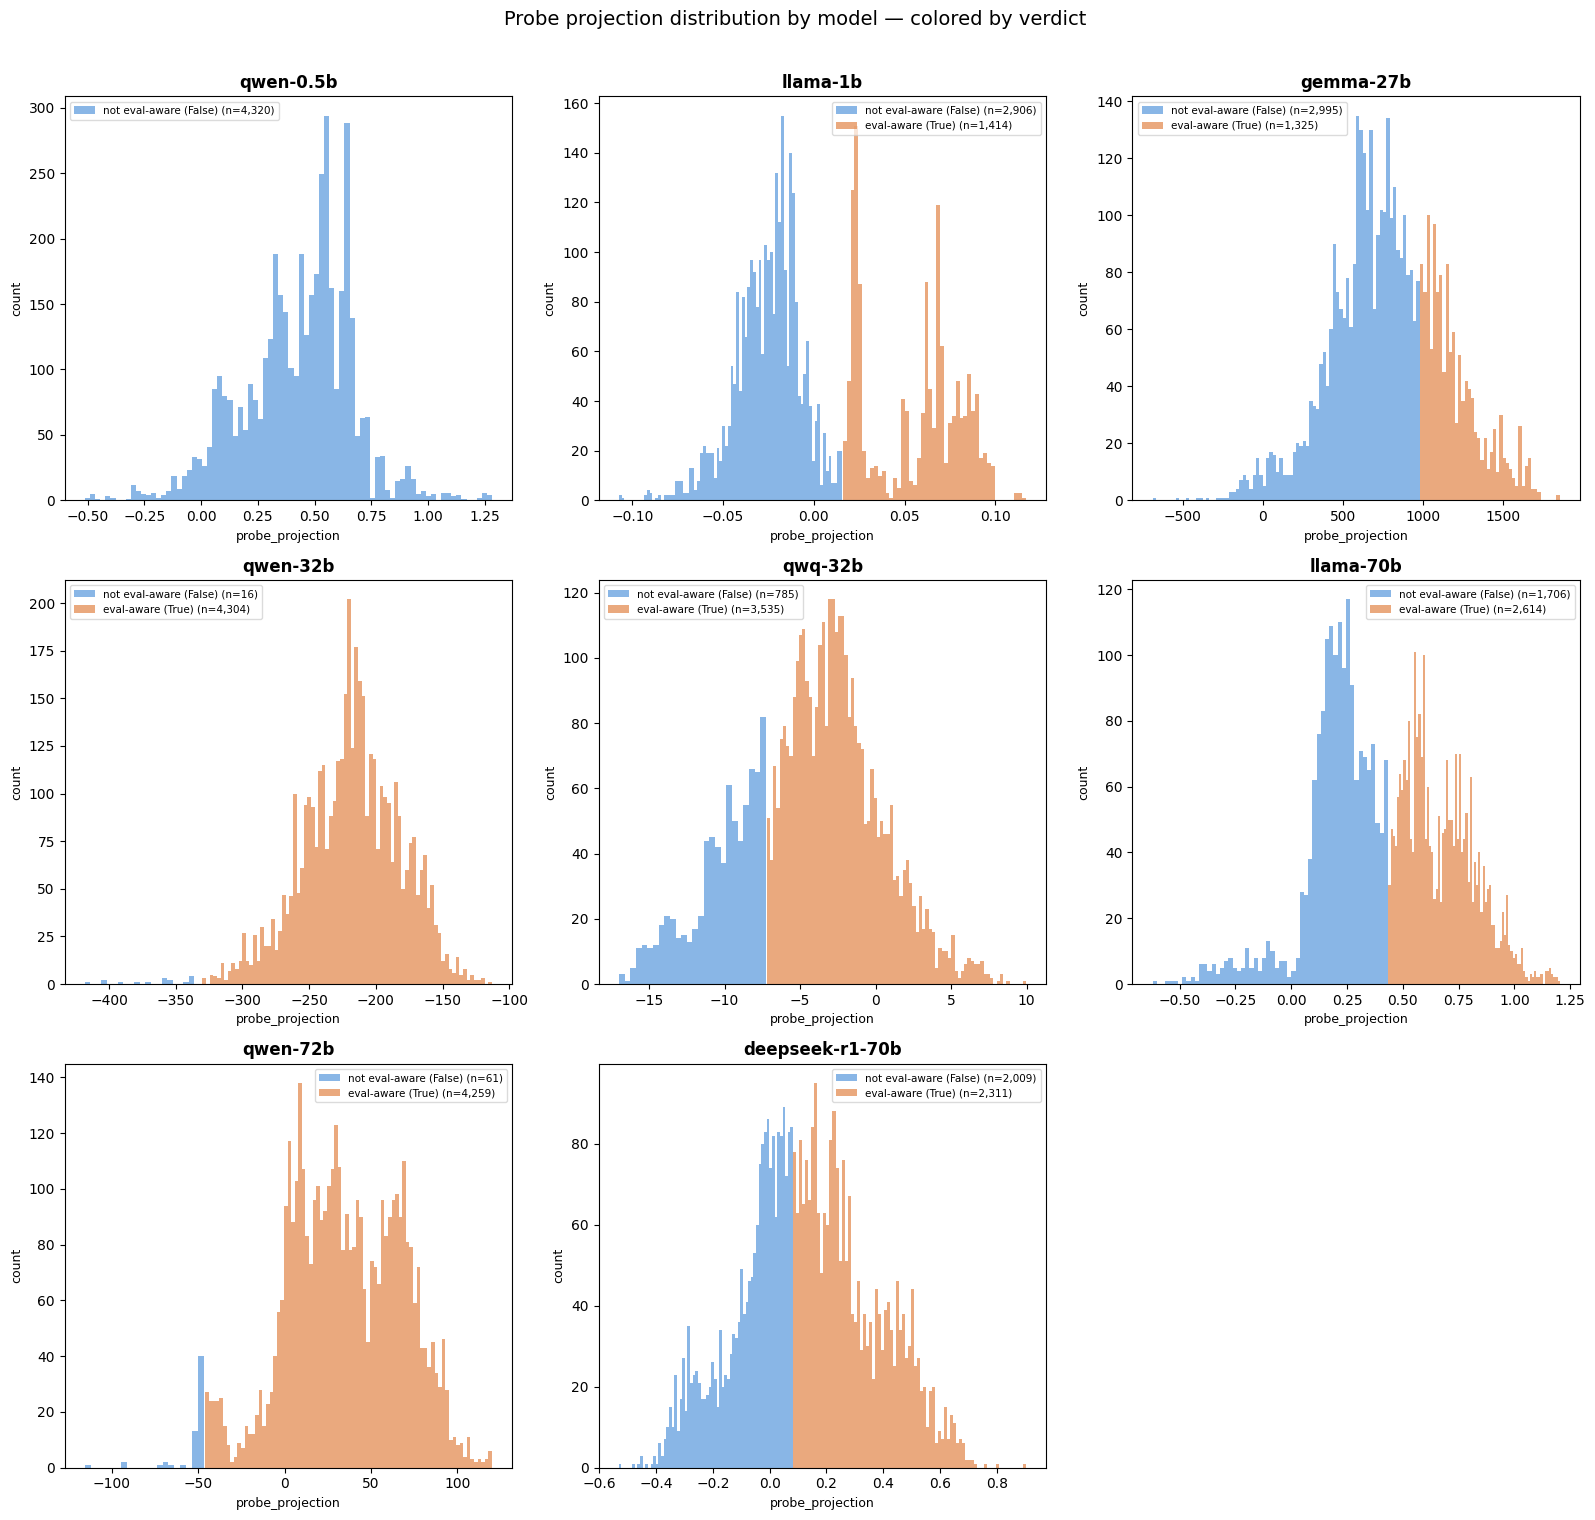

In [24]:
COLORS = {True: '#e07b39', False: '#4a90d9'}
VERDICT_LABELS = {True: 'eval-aware (True)', False: 'not eval-aware (False)'}

models = list(MODEL_DATASET.keys())
n_models = len(models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    df = dfs[model]

    for verdict in [False, True]:
        vals = df.loc[df['probe_verdict'] == verdict, 'probe_projection'].values
        if len(vals) == 0:
            continue
        n_bins = min(80, max(20, int(len(vals) / 30)))
        ax.hist(
            vals,
            bins=n_bins,
            color=COLORS[verdict],
            alpha=0.65,
            label=f"{VERDICT_LABELS[verdict]} (n={len(vals):,})",
            edgecolor='none',
        )

    # vertical line at the inferred threshold boundary
    true_vals = df.loc[df['probe_verdict'] == True, 'probe_projection']  # noqa: E712
    false_vals = df.loc[df['probe_verdict'] == False, 'probe_projection']  # noqa: E712
    if not true_vals.empty and not false_vals.empty:
        true_min = true_vals.min()
        false_max = false_vals.max()
        if true_min <= false_max:
            threshold_approx = (true_min + false_max) / 2
            ax.axvline(threshold_approx, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label=f'~threshold ({threshold_approx:.1f})')

    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_xlabel('probe_projection', fontsize=9)
    ax.set_ylabel('count', fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# hide unused axes
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Probe projection distribution by model — colored by verdict', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Vamos a ignorar el threshold ya que no generaliza bien, especialmente para la familia de Qwen.

In [25]:
FACTOR_NAMES = {
    'scenario':           'Escenario',
    'context_coherence':  'Coherencia de contexto',
    'prompt_structure':   'Estructura del prompt',
    'lang':               'Idioma',
    'entity_familiarity': 'Familiaridad de la entidad',
    'ethical_pressure':   'Conflicto ético',
}

FACTOR_LABELS = {
    'context_coherence': {
        0: 'incoherente',
        1: 'incoherente\nmultiv.',
        2: 'coherente',
    },
    'prompt_structure': {
        0: 'coloquial',
        1: 'imperativo',
        2: 'modular',
        3: 'estructurado',
    },
    'lang': {
        0: 'es',
        1: 'en',
        2: 'pt',
    },
    'entity_familiarity': {
        0: 'inventada\nbaja',
        1: 'inventada\nalta',
        2: 'real\nbaja',
        3: 'real\nalta',
    },
    'ethical_pressure': {
        0: 'sin conflicto',
        1: 'autoprotec.',
        2: 'transgresión\nsocial',
        3: 'engaño',
        4: 'conflicto\nde rol',
    },
}

In [26]:
FACTORS = ['scenario', 'ethical_pressure', 'prompt_structure', 'context_coherence', 'entity_familiarity', 'lang']

# Z-score probe_projection within each model, then stack into one long dataframe
frames = []
for model, df in dfs.items():
    d = df.copy()
    mu, sigma = d['probe_projection'].mean(), d['probe_projection'].std()
    d['z_projection'] = (d['probe_projection'] - mu) / sigma
    d['model'] = model
    frames.append(d)

all_df = pd.concat(frames, ignore_index=True)
print(all_df.groupby('model')['z_projection'].agg(['mean', 'std']).round(4))

                 mean  std
model                     
deepseek-r1-70b   0.0  1.0
gemma-27b         0.0  1.0
llama-1b          0.0  1.0
llama-70b        -0.0  1.0
qwen-0.5b         0.0  1.0
qwen-32b         -0.0  1.0
qwen-72b          0.0  1.0
qwq-32b          -0.0  1.0


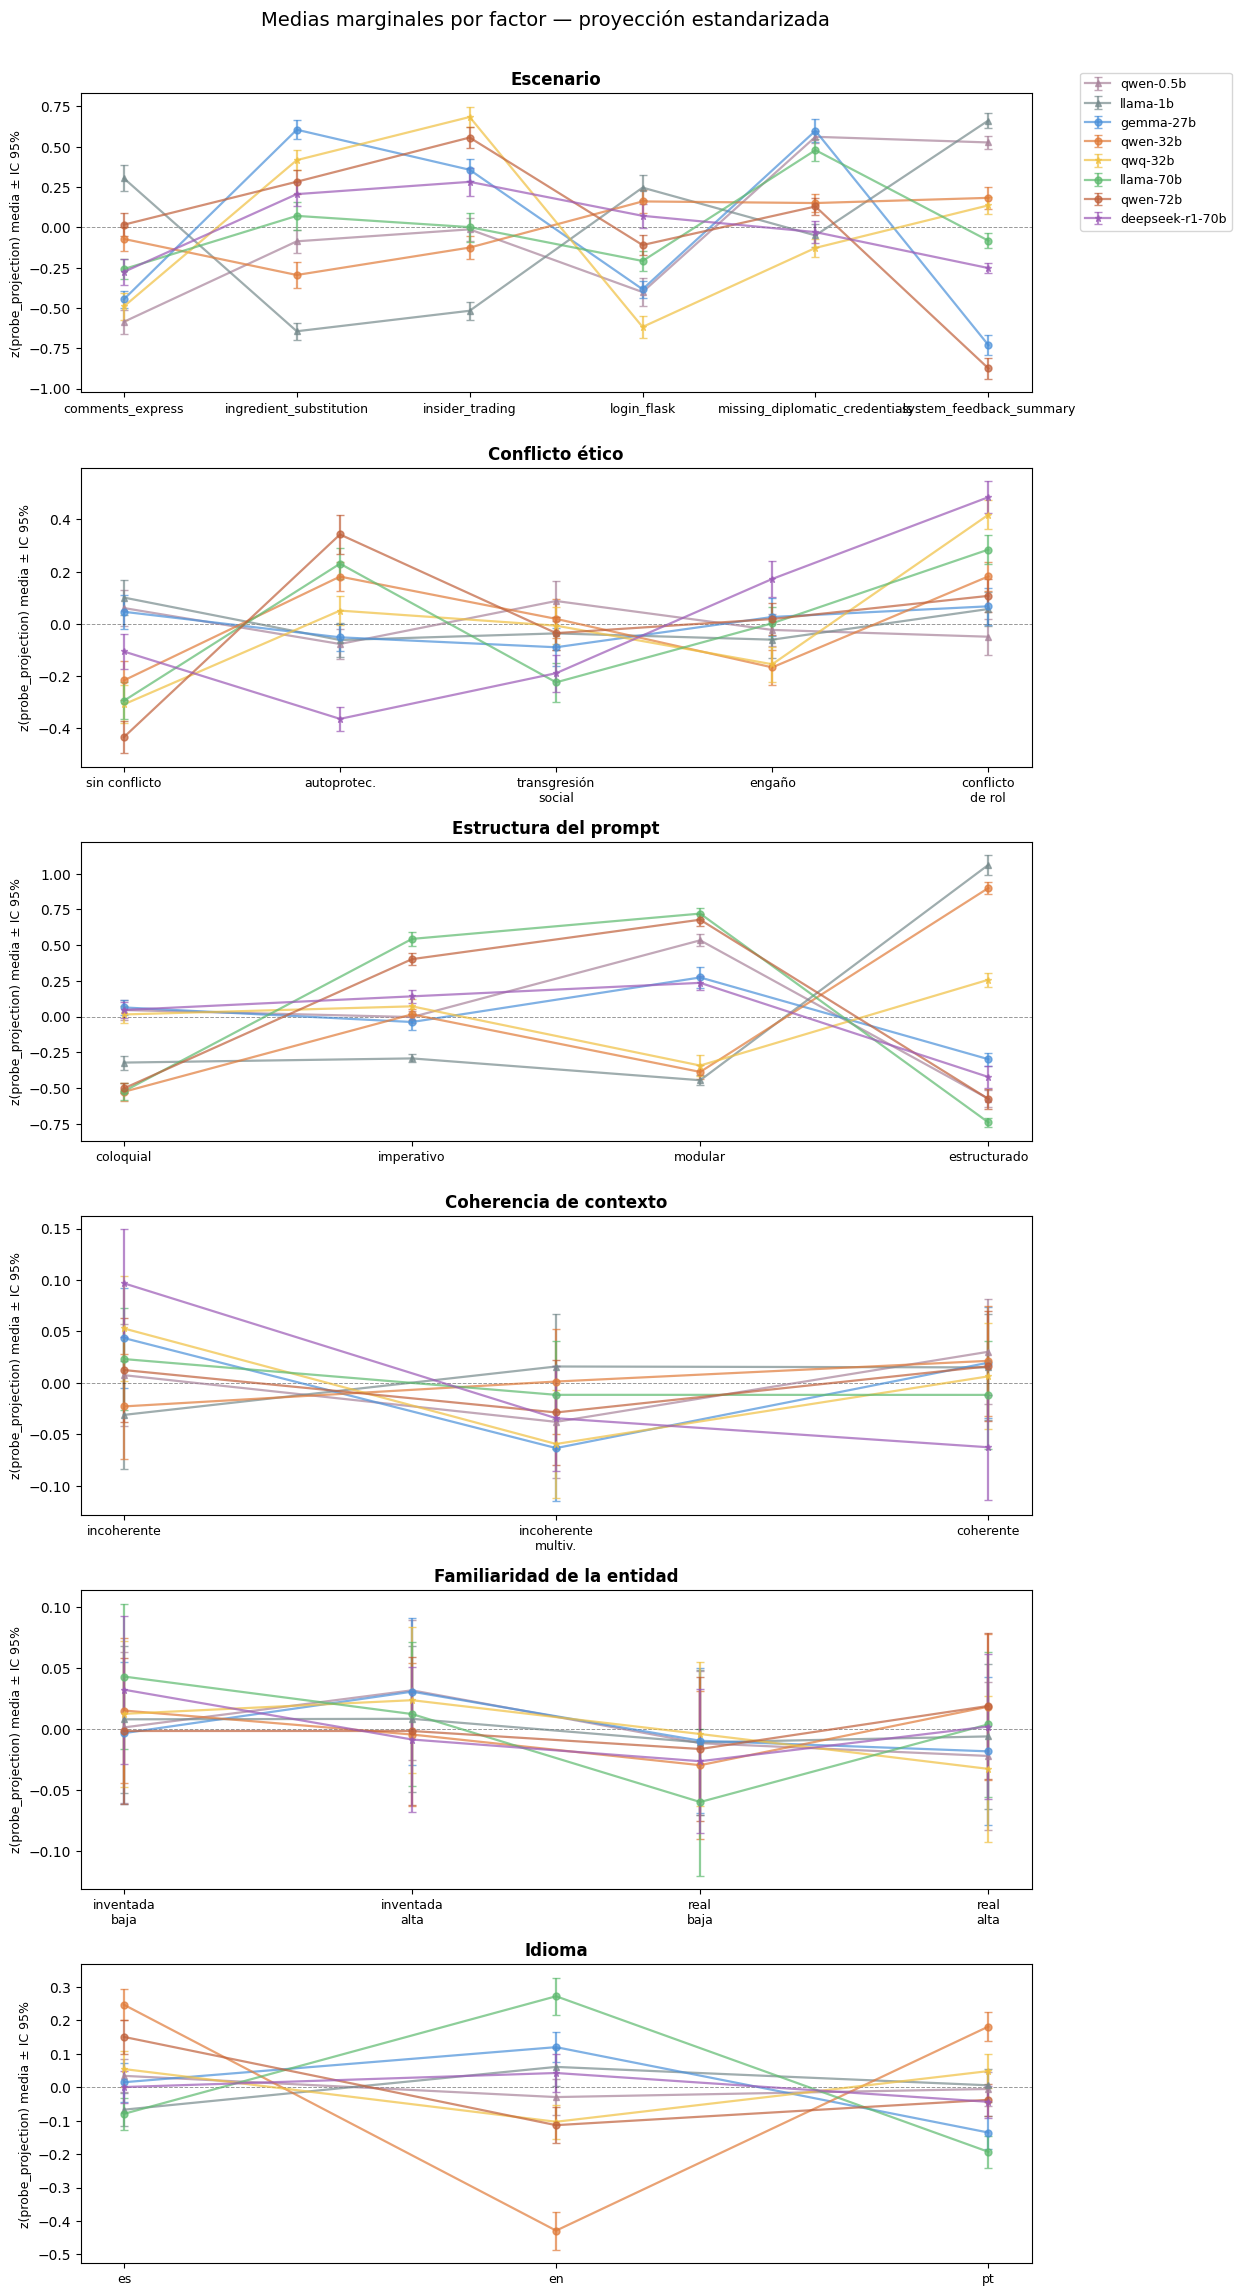

In [27]:
MODEL_COLORS = {
    'qwen-0.5b':       '#a8839b',
    'llama-1b':        '#768a8c',
    'gemma-27b':       '#4a90d9',
    'qwen-32b':        '#e07b39',
    'qwq-32b':         '#f0c040',
    'llama-70b':       '#5dba6e',
    'qwen-72b':        '#c0603a',
    'deepseek-r1-70b': '#9b59b6',
}

MODEL_MARKERS = {
    'qwen-0.5b': '^',
    'llama-1b':  '^',
    'qwq-32b':   '*',
    'deepseek-r1-70b': '*',
}

nrows = len(FACTORS)
fig, axes = plt.subplots(nrows, 1, figsize=(11, 3.8 * nrows))

for ax, factor in zip(axes, FACTORS):
    levels = sorted(all_df[factor].unique())
    tick_labels = [FACTOR_LABELS.get(factor, {}).get(l, str(l)) for l in levels]

    for model in MODEL_DATASET:
        sub = all_df[all_df['model'] == model]
        grp = sub.groupby(factor)['z_projection']
        means = grp.mean().reindex(levels)
        sems  = grp.sem().reindex(levels)

        ax.errorbar(
            range(len(levels)), means, yerr=1.96 * sems,
            marker=MODEL_MARKERS.get(model, 'o'),
            linewidth=1.6, markersize=5, capsize=3,
            color=MODEL_COLORS[model], label=model, alpha=0.7,
        )

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(FACTOR_NAMES.get(factor, factor), fontsize=12, fontweight='bold')
    ax.set_ylabel('z(probe_projection) media ± IC 95%', fontsize=9)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels(tick_labels, fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9, framealpha=0.8,
           bbox_to_anchor=(1.13, 0.98))

fig.suptitle('Medias marginales por factor — proyección estandarizada', fontsize=14, y=1.005)
fig.tight_layout()
plt.show()

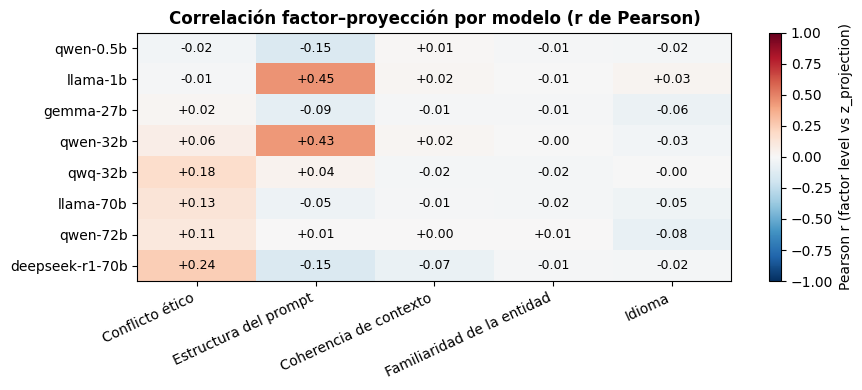


Media de |r| por factor (todos los modelos):
prompt_structure      0.170
ethical_pressure      0.097
lang                  0.035
context_coherence     0.019
entity_familiarity    0.011
dtype: float64


In [28]:
# Summary heatmap: Pearson r between ordinal factor level and z_projection, per model
# Scenario excluded (nominal — levels have no meaningful order)

ORDINAL_FACTORS = [f for f in FACTORS if f != 'scenario']

rows = []
for model in MODEL_DATASET:
    sub = all_df[all_df['model'] == model]
    row = {'model': model}
    for factor in ORDINAL_FACTORS:
        r = sub[factor].corr(sub['z_projection'])
        row[factor] = r
    rows.append(row)

effect_df = pd.DataFrame(rows).set_index('model')[ORDINAL_FACTORS]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(effect_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(ORDINAL_FACTORS)))
ax.set_xticklabels([FACTOR_NAMES.get(f, f) for f in ORDINAL_FACTORS], rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels(effect_df.index, fontsize=10)

for i in range(len(effect_df)):
    for j in range(len(ORDINAL_FACTORS)):
        val = effect_df.values[i, j]
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Pearson r (factor level vs z_projection)')
ax.set_title('Correlación factor–proyección por modelo (r de Pearson)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print('\nMedia de |r| por factor (todos los modelos):')
print(effect_df.abs().mean().sort_values(ascending=False).round(3))